In [8]:
from fastdownload import download_url
from fastai.vision.all import *
from duckduckgo_search import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *
from ddgs import DDGS
import time, json

In [9]:
def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = []
        for r in ddgs.images(keywords, max_results=max_images):
            results.append(r['image'])
            time.sleep(0.1)  # avoid rate limiting
        return L(results)


In [10]:
urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/2137850/pexels-photo-2137850.jpeg?cs=srgb&dl=animal-animal-photography-beautiful-2137850.jpg&fm=jpg'

In [11]:
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

Path('bird.jpg')

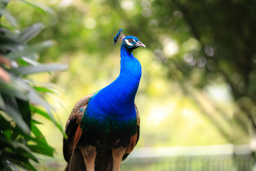

In [12]:
im = Image.open(dest)
im.to_thumb(256,256)

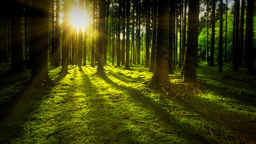

In [13]:
download_url(search_images('forest photos', max_images=1)[0], 'forest.jpg', show_progress=False)
Image.open('forest.jpg').to_thumb(256,256)

In [14]:
searches = 'forest','bird'
path = Path('bird_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in th

In [15]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/Users/bioinfo/.local/share/uv/python/cpython-3.13.5-macos-aarch64-none/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=26918) is multi-threaded, use of fork() may lead to deadlocks in th

0

/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)
/Users/bioinfo/Projects/applied-data/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:684: DeprecationWarnin

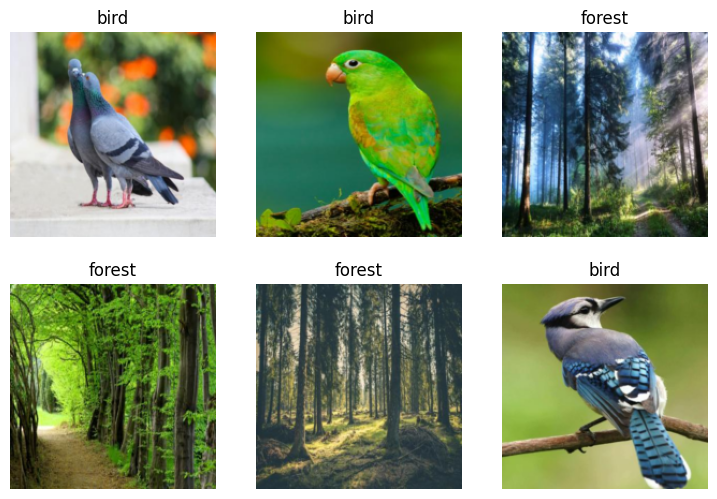

In [16]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)



In [18]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/bioinfo/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:08<00:00, 5.78MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.476361,1.082910,0.384615,00:05


epoch,train_loss,valid_loss,error_rate,time
0,0.937532,0.819151,0.384615,00:00
1,0.940378,0.336775,0.153846,00:00
2,0.693977,0.151875,0.076923,00:00


In [19]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: bird.
Probability it's a bird: 0.9993
